In [1]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



In [3]:
LAM_BASE = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
}

In [6]:

def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder


In [8]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=6: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs6/lam3_-4.6097100000e-06
NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09


In [29]:
def load_base_summary_row(NEQS, param_name, base_value, base_path_root):
    summary_file = f"{base_path_root}/neqs{NEQS}/neqs{NEQS}_summary.csv"
    df = pd.read_csv(summary_file)

    idx = np.argmin(np.abs(df[param_name] - base_value))
    return df.iloc[idx]

rows = []

for NEQS, (param_name, base_val) in LAM_BASE.items():
    row = load_base_summary_row(NEQS, param_name, base_val, base_path_root)

    rows.append({
        "NEQS": NEQS,
        "param": param_name,
        "value": row[param_name],
        "n_s": row["n_s"],
        "r": row["r"],
        "original_N_end": row["original_N_end"],
        "spectrum_N_start": row["spectrum_N_start"],
        "path_N_end": row["path_N_end"],
    })

base_summary_df = pd.DataFrame(rows)
print(base_summary_df.to_string(index=False))

#Compare relative to 6 base
ref = base_summary_df.loc[base_summary_df["NEQS"] == 6, "original_N_end"].iloc[0]

base_summary_df["delta_N_vs_NEQS6"] = (
    base_summary_df["original_N_end"] - ref
)

print(base_summary_df.to_string(index=False))

 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0
 NEQS param         value      n_s        r  original_N_end  spectrum_N_start  path_N_end  delta_N_vs_NEQS6
    6  lam3 -4.609710e-06 0.965678 0.003454      939.163572          0.000160        60.0          0.000000
    7  lam4  6.870650e-08 0.967201 0.003158      941.837071          0.000156        60.0          2.673499
    8  lam5 -8.924610e-09 0.969485 0.002737      946.349733          0.000156        60.0          7.186161


In [27]:
def plot_H_shape_only_with_frac_error_limitedN(
    base_path_root,
    save_name=None,
    suptitle=None,
    N_ref=60.0,
    ref_floor=1e-20,
    frac_floor=1e-30,
    N_min=20.0,
    N_max=60.0,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    base_models = {
        6: ("lam3", -4.60971e-6),
        7: ("lam4",  6.87065e-8),
        8: ("lam5", -8.92461e-9),
    }

    colors = {
        6: "blue",
        7: "orange",
        8: "green",
    }

    def load_path_data(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )
        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
        )
        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_curve_at_Nref(N, Y):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (N_use.min() <= N_ref <= N_use.max()):
            raise ValueError(
                f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < ref_floor:
            raise ValueError(f"Reference too small: {Y_ref:.3e}")

        return N_use, Y_use / Y_ref, Y_ref

    def fractional_difference_on_overlap(x, y, x_ref, y_ref):
        x, y = prepare_increasing(x, y)
        x_ref, y_ref = prepare_increasing(x_ref, y_ref)

        xmin = max(np.min(x), np.min(x_ref))
        xmax = min(np.max(x), np.max(x_ref))

        mask = (x >= xmin) & (x <= xmax)

        x_use = x[mask]
        y_use = y[mask]

        y_ref_interp = np.interp(x_use, x_ref, y_ref)

        frac = (y_use - y_ref_interp) / np.where(
            np.abs(y_ref_interp) > frac_floor,
            y_ref_interp,
            np.nan,
        )

        return x_use, frac

    def apply_N_window(N, Y):
        mask = (N >= N_min) & (N <= N_max)
        return N[mask], Y[mask]

    # Load + normalize
    model_data = {}

    for NEQS, (param_name, base_value) in base_models.items():
        data = load_path_data(NEQS, param_name, base_value)

        N = data[:, NEQS]
        H = data[:, 1]

        Nn, Hnorm, Hstar = normalize_curve_at_Nref(N, H)
        Nn, Hnorm = apply_N_window(Nn, Hnorm)

        model_data[NEQS] = {
            "N_norm": Nn,
            "H_norm": Hnorm,
            "H_ref": Hstar,
            "param_name": param_name,
            "base_value": base_value,
        }

    ref_curve = model_data[6]

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

    # Top: shape-only H
    for NEQS, d in model_data.items():
        axs[0].plot(
            d["N_norm"],
            d["H_norm"],
            lw=2,
            color=colors[NEQS],
            label=rf"NEQS={NEQS}, {d['param_name']}={d['base_value']:.2e}",
        )

    axs[0].set_title(rf"Shape-only $H(N)/H({N_ref})$")
    axs[0].set_ylabel(rf"$H/H({N_ref})$")
    axs[0].invert_xaxis()
    axs[0].grid(True, alpha=0.25)
    axs[0].legend(fontsize=8)

    # Bottom: fractional difference
    for NEQS, d in model_data.items():
        N_use, frac = fractional_difference_on_overlap(
            d["N_norm"],
            d["H_norm"],
            ref_curve["N_norm"],
            ref_curve["H_norm"],
        )

        axs[1].plot(
            N_use,
            frac,
            lw=2,
            color=colors[NEQS],
            label=f"NEQS={NEQS}",
        )

    axs[1].axhline(0, color="black", linestyle="--", alpha=0.5)
    axs[1].set_title(r"Fractional difference vs NEQS=6 base")
    axs[1].set_xlabel(r"$N$")
    axs[1].set_ylabel(r"Fractional difference")
    axs[1].invert_xaxis()
    axs[1].grid(True, alpha=0.25)
    axs[1].legend(fontsize=8)

    if suptitle:
        fig.suptitle(suptitle, fontsize=15)

    if save_name is None:
        save_name = "H_shape_only_windowed.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

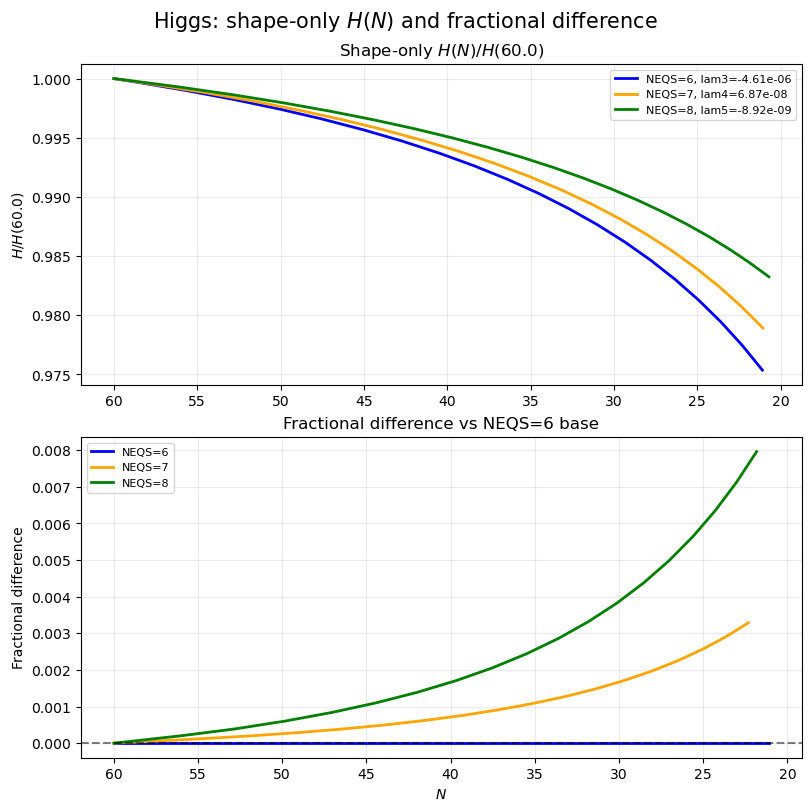

In [28]:
plot_H_shape_only_with_frac_error_limitedN(
    base_path_root=base_path_root,
    save_name="higgs_H_shape_only_with_frac_error_limitedN.png",
    suptitle=r"Higgs: shape-only $H(N)$ and fractional difference",
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
)

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

LAM_BASE = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
}

def plot_base_spectra_overlay_k(
    base_path_root,
    base_params=LAM_BASE,
    k_ref=0.05,
    normalize=True,
    save_name=None,
):
    colors = {
        6: "blue",
        7: "orange",
        8: "green",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}"
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    ax_s, ax_t = axes

    for NEQS, (param_name, value) in base_params.items():
        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

        if normalize:
            k_s, Ps_plot, Ps_ref = normalize_at_ref(k_s, Ps)
            k_t, Pt_plot, Pt_ref = normalize_at_ref(k_t, Pt)
            ylab_s = rf"$P_s(k)/P_s({k_ref})$"
            ylab_t = rf"$P_t(k)/P_t({k_ref})$"
        else:
            k_s, Ps_plot = prepare_increasing(k_s, Ps)
            k_t, Pt_plot = prepare_increasing(k_t, Pt)
            ylab_s = r"$P_s(k)$"
            ylab_t = r"$P_t(k)$"

        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"

        ax_s.loglog(
            k_s,
            Ps_plot,
            color=colors.get(NEQS, None),
            lw=2,
            label=label,
        )

        ax_t.loglog(
            k_t,
            Pt_plot,
            color=colors.get(NEQS, None),
            lw=2,
            label=label,
        )

    ax_s.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_t.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_s.set_title("Base scalar spectra")
    ax_t.set_title("Base tensor spectra")

    ax_s.set_xlabel(r"$k$")
    ax_t.set_xlabel(r"$k$")

    ax_s.set_ylabel(ylab_s)
    ax_t.set_ylabel(ylab_t)

    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    fig.suptitle("Base spectra overlay: NEQS 6–8", fontsize=15)

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()

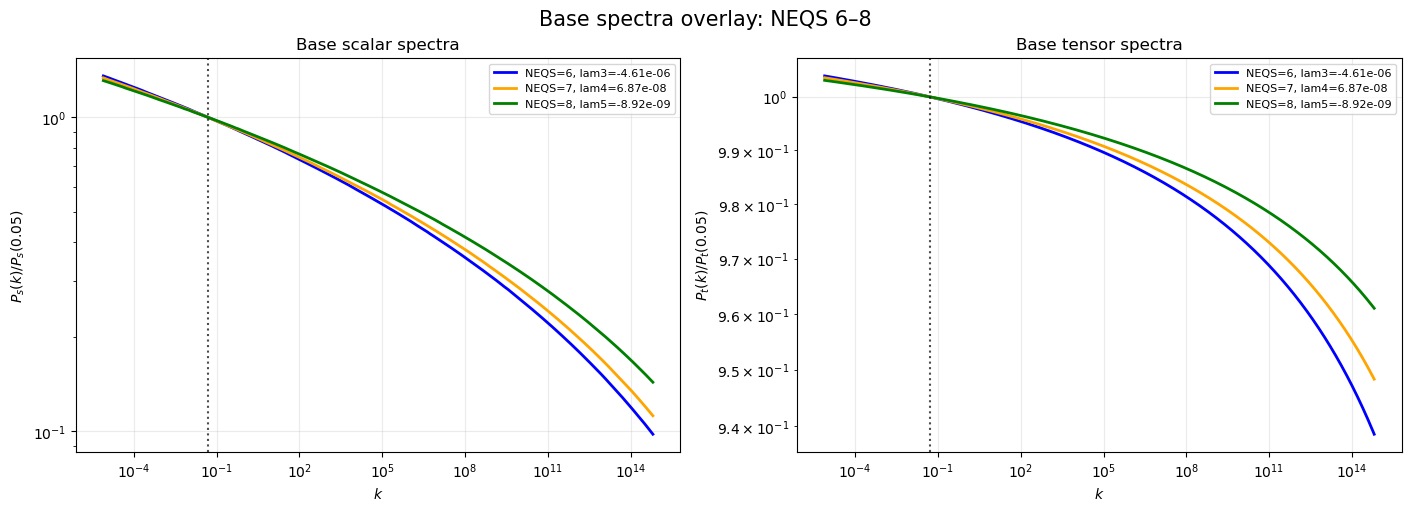

In [13]:
plot_base_spectra_overlay_k(
    base_path_root=base_path_root,
    normalize=True,
    k_ref=0.05,
    save_name="base_spectra_overlay_neqs6_8.png",
)

In [30]:
def plot_big_base_curves_summary_neqs6_8(
    base_path_root,
    base_params=None,
    ref_NEQS=6,
    k_ref=0.05,
    N_ref=60.0,
    ref_floor_spec=1e-30,
    ref_floor_bg=1e-20,
    frac_floor=1e-100,
    H_scale=1.0,
    V_scale=1.0,
    k_max_scalar=10.0,
    save_name=None,
    suptitle=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    colors = {
        6: "blue",
        7: "orange",
        8: "green",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def load_path(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = folder_for(NEQS, param_name, value)

        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat"
        )

        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_curve_at_ref(x, y, x_ref, ref_floor):
        x_use, y_use = prepare_increasing(x, y)

        if x_ref < np.min(x_use) or x_ref > np.max(x_use):
            raise ValueError(
                f"x_ref={x_ref} outside range [{np.min(x_use)}, {np.max(x_use)}]"
            )

        y_ref = np.interp(x_ref, x_use, y_use)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(f"Reference value too small: {y_ref:.3e}")

        return x_use, y_use / y_ref, y_ref

    def fractional_difference_on_common_x(x_base, y_base, x_cmp, y_cmp):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        mask = (x_base >= xmin) & (x_base <= xmax)

        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / np.where(
            np.abs(y_base_use) > frac_floor,
            y_base_use,
            np.nan,
        )

        return x_use, frac

    def extract_cols(path_data, NEQS):
        phi = path_data[:, 0]
        H = path_data[:, 1]
        N = path_data[:, NEQS]
        V = path_data[:, NEQS + 1]
        return phi, H, N, V

    def get_normalized_H_vs_N(path_data, NEQS):
        _, H, N, _ = extract_cols(path_data, NEQS)
        return normalize_curve_at_ref(N, H, N_ref, ref_floor_bg)

    def get_normalized_V_vs_phi(path_data, NEQS):
        phi_raw, _, N_raw, V_raw = extract_cols(path_data, NEQS)

        N_use, phi_use = prepare_increasing(N_raw, phi_raw)
        _, V_use = prepare_increasing(N_raw, V_raw)

        if N_ref < np.min(N_use) or N_ref > np.max(N_use):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        V_ref = np.interp(N_ref, N_use, V_use)

        if np.abs(V_ref) < ref_floor_bg:
            raise ValueError(f"Reference V too small at N_ref={N_ref}: {V_ref:.3e}")

        V_norm = V_use / V_ref

        return phi_use, V_norm, V_ref

    # ---------------- load reference ----------------
    ref_param, ref_value = base_params[ref_NEQS]

    k_s_ref, Ps_ref, k_t_ref, Pt_ref = load_specs(ref_NEQS, ref_param, ref_value)
    path_ref = load_path(ref_NEQS, ref_param, ref_value)

    k_s_ref, Ps_ref_norm, _ = normalize_curve_at_ref(
        k_s_ref, Ps_ref, k_ref, ref_floor_spec
    )
    k_t_ref, Pt_ref_norm, _ = normalize_curve_at_ref(
        k_t_ref, Pt_ref, k_ref, ref_floor_spec
    )

    N_H_ref, H_ref_norm, _ = get_normalized_H_vs_N(path_ref, ref_NEQS)
    phi_V_ref, V_ref_norm, _ = get_normalized_V_vs_phi(path_ref, ref_NEQS)

    # ---------------- figure ----------------
    fig = plt.figure(figsize=(18, 18), constrained_layout=True)
    gs = GridSpec(4, 2, figure=fig)

    ax_ps       = fig.add_subplot(gs[0, 0])
    ax_pt       = fig.add_subplot(gs[0, 1])
    ax_ps_err   = fig.add_subplot(gs[1, 0])
    ax_pt_err   = fig.add_subplot(gs[1, 1])
    ax_h        = fig.add_subplot(gs[2, 0])
    ax_h_err    = fig.add_subplot(gs[2, 1])
    ax_vphi     = fig.add_subplot(gs[3, 0])
    ax_vphi_err = fig.add_subplot(gs[3, 1])

    stats_rows = []

    # ---------------- loop over base curves ----------------
    for NEQS, (param_name, value) in base_params.items():
        color = colors.get(NEQS, None)
        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"

        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)
        path_data = load_path(NEQS, param_name, value)

        k_s_use, Ps_norm, _ = normalize_curve_at_ref(
            k_s, Ps, k_ref, ref_floor_spec
        )
        k_t_use, Pt_norm, _ = normalize_curve_at_ref(
            k_t, Pt, k_ref, ref_floor_spec
        )

        N_H, H_norm, _ = get_normalized_H_vs_N(path_data, NEQS)
        phi_V, V_norm, _ = get_normalized_V_vs_phi(path_data, NEQS)

        k_ps_err, frac_ps = fractional_difference_on_common_x(
            k_s_ref, Ps_ref_norm, k_s_use, Ps_norm
        )
        k_pt_err, frac_pt = fractional_difference_on_common_x(
            k_t_ref, Pt_ref_norm, k_t_use, Pt_norm
        )
        N_h_err, frac_h = fractional_difference_on_common_x(
            N_H_ref, H_ref_norm, N_H, H_norm
        )
        phi_v_err, frac_v = fractional_difference_on_common_x(
            phi_V_ref, V_ref_norm, phi_V, V_norm
        )

        mask_k = k_s_use <= k_max_scalar
        mask_k_err = k_ps_err <= k_max_scalar

        ax_ps.plot(k_s_use[mask_k], Ps_norm[mask_k], color=color, lw=2, label=label)
        ax_pt.plot(k_t_use, Pt_norm, color=color, lw=2, label=label)

        ax_ps_err.plot(k_ps_err[mask_k_err], frac_ps[mask_k_err], color=color, lw=2, label=label)
        ax_pt_err.plot(k_pt_err, frac_pt, color=color, lw=2, label=label)

        ax_h.plot(N_H, H_scale * H_norm, color=color, lw=2, label=label)
        ax_h_err.plot(N_h_err, frac_h, color=color, lw=2, label=label)

        ax_vphi.plot(phi_V, V_scale * V_norm, color=color, lw=2, label=label)
        ax_vphi_err.plot(phi_v_err, frac_v, color=color, lw=2, label=label)

        stats_rows.append({
            "NEQS": NEQS,
            "param": param_name,
            "value": value,
            "mean_dPs_pct": 100 * np.nanmean(frac_ps[mask_k_err]),
            "max_dPs_pct": 100 * np.nanmax(np.abs(frac_ps[mask_k_err])),
            "mean_dPt_pct": 100 * np.nanmean(frac_pt),
            "max_dPt_pct": 100 * np.nanmax(np.abs(frac_pt)),
            "mean_dH_pct": 100 * np.nanmean(frac_h),
            "max_dH_pct": 100 * np.nanmax(np.abs(frac_h)),
            "mean_dV_pct": 100 * np.nanmean(frac_v),
            "max_dV_pct": 100 * np.nanmax(np.abs(frac_v)),
        })

    stats_df = pd.DataFrame(stats_rows)

    # ---------------- titles ----------------
    ax_ps.set_title(rf"Normalized scalar spectrum: $P_s(k)/P_s({k_ref})$")
    ax_pt.set_title(rf"Normalized tensor spectrum: $P_t(k)/P_t({k_ref})$")
    ax_ps_err.set_title(r"Fractional error in normalized $P_s(k)$ vs NEQS=6")
    ax_pt_err.set_title(r"Fractional error in normalized $P_t(k)$ vs NEQS=6")

    ax_h.set_title(rf"Normalized Hubble parameter: $H(N)/H({N_ref})$")
    ax_h_err.set_title(r"Fractional error in normalized $H(N)$ vs NEQS=6")

    ax_vphi.set_title(rf"Normalized potential: $V(\phi)/V(N={N_ref})$")
    ax_vphi_err.set_title(r"Fractional error in normalized $V(\phi)$ vs NEQS=6")

    # ---------------- labels ----------------
    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$(P_s-P_{s,6})/P_{s,6}$")
    ax_pt_err.set_ylabel(r"$(P_t-P_{t,6})/P_{t,6}$")

    ax_h.set_ylabel(rf"$H/H({N_ref})$")
    ax_h_err.set_ylabel(r"$(H-H_6)/H_6$")

    ax_vphi.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_vphi_err.set_ylabel(r"$(V-V_6)/V_6$")

    for ax in [ax_ps_err, ax_pt_err]:
        ax.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_h.set_xlabel(r"$N$")
    ax_h_err.set_xlabel(r"$N$")
    ax_vphi.set_xlabel(r"$\phi$")
    ax_vphi_err.set_xlabel(r"$\phi$")

    # ---------------- styling ----------------
    for ax in [ax_ps, ax_pt]:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)

    for ax in [ax_ps_err, ax_pt_err]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.grid(True, alpha=0.25)

    for ax in [ax_h, ax_h_err]:
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

    for ax in [ax_h_err, ax_vphi_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.5)

    for ax in [ax_vphi, ax_vphi_err]:
        ax.grid(True, alpha=0.25)

    for ax in [ax_ps, ax_pt, ax_h, ax_vphi]:
        ax.legend(fontsize=8)

    if suptitle is None:
        suptitle = "Normalized spectra and background summary for base NEQS 6–8 curves"

    fig.suptitle(suptitle, fontsize=17)

    if save_name is None:
        save_name = "base_neqs6_8_big_normalized_summary.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    print("\n=== Summary Statistics (% difference from NEQS=6 base) ===\n")
    display_df = stats_df.copy()
    for col in display_df.columns:
        if col in ["NEQS", "param"]:
            continue
        elif col == "value":
            display_df[col] = display_df[col].map(lambda x: f"{x:.3e}")
        else:
            display_df[col] = display_df[col].map(lambda x: f"{x:.3f}%")

    print(display_df.to_string(index=False))

    return stats_df

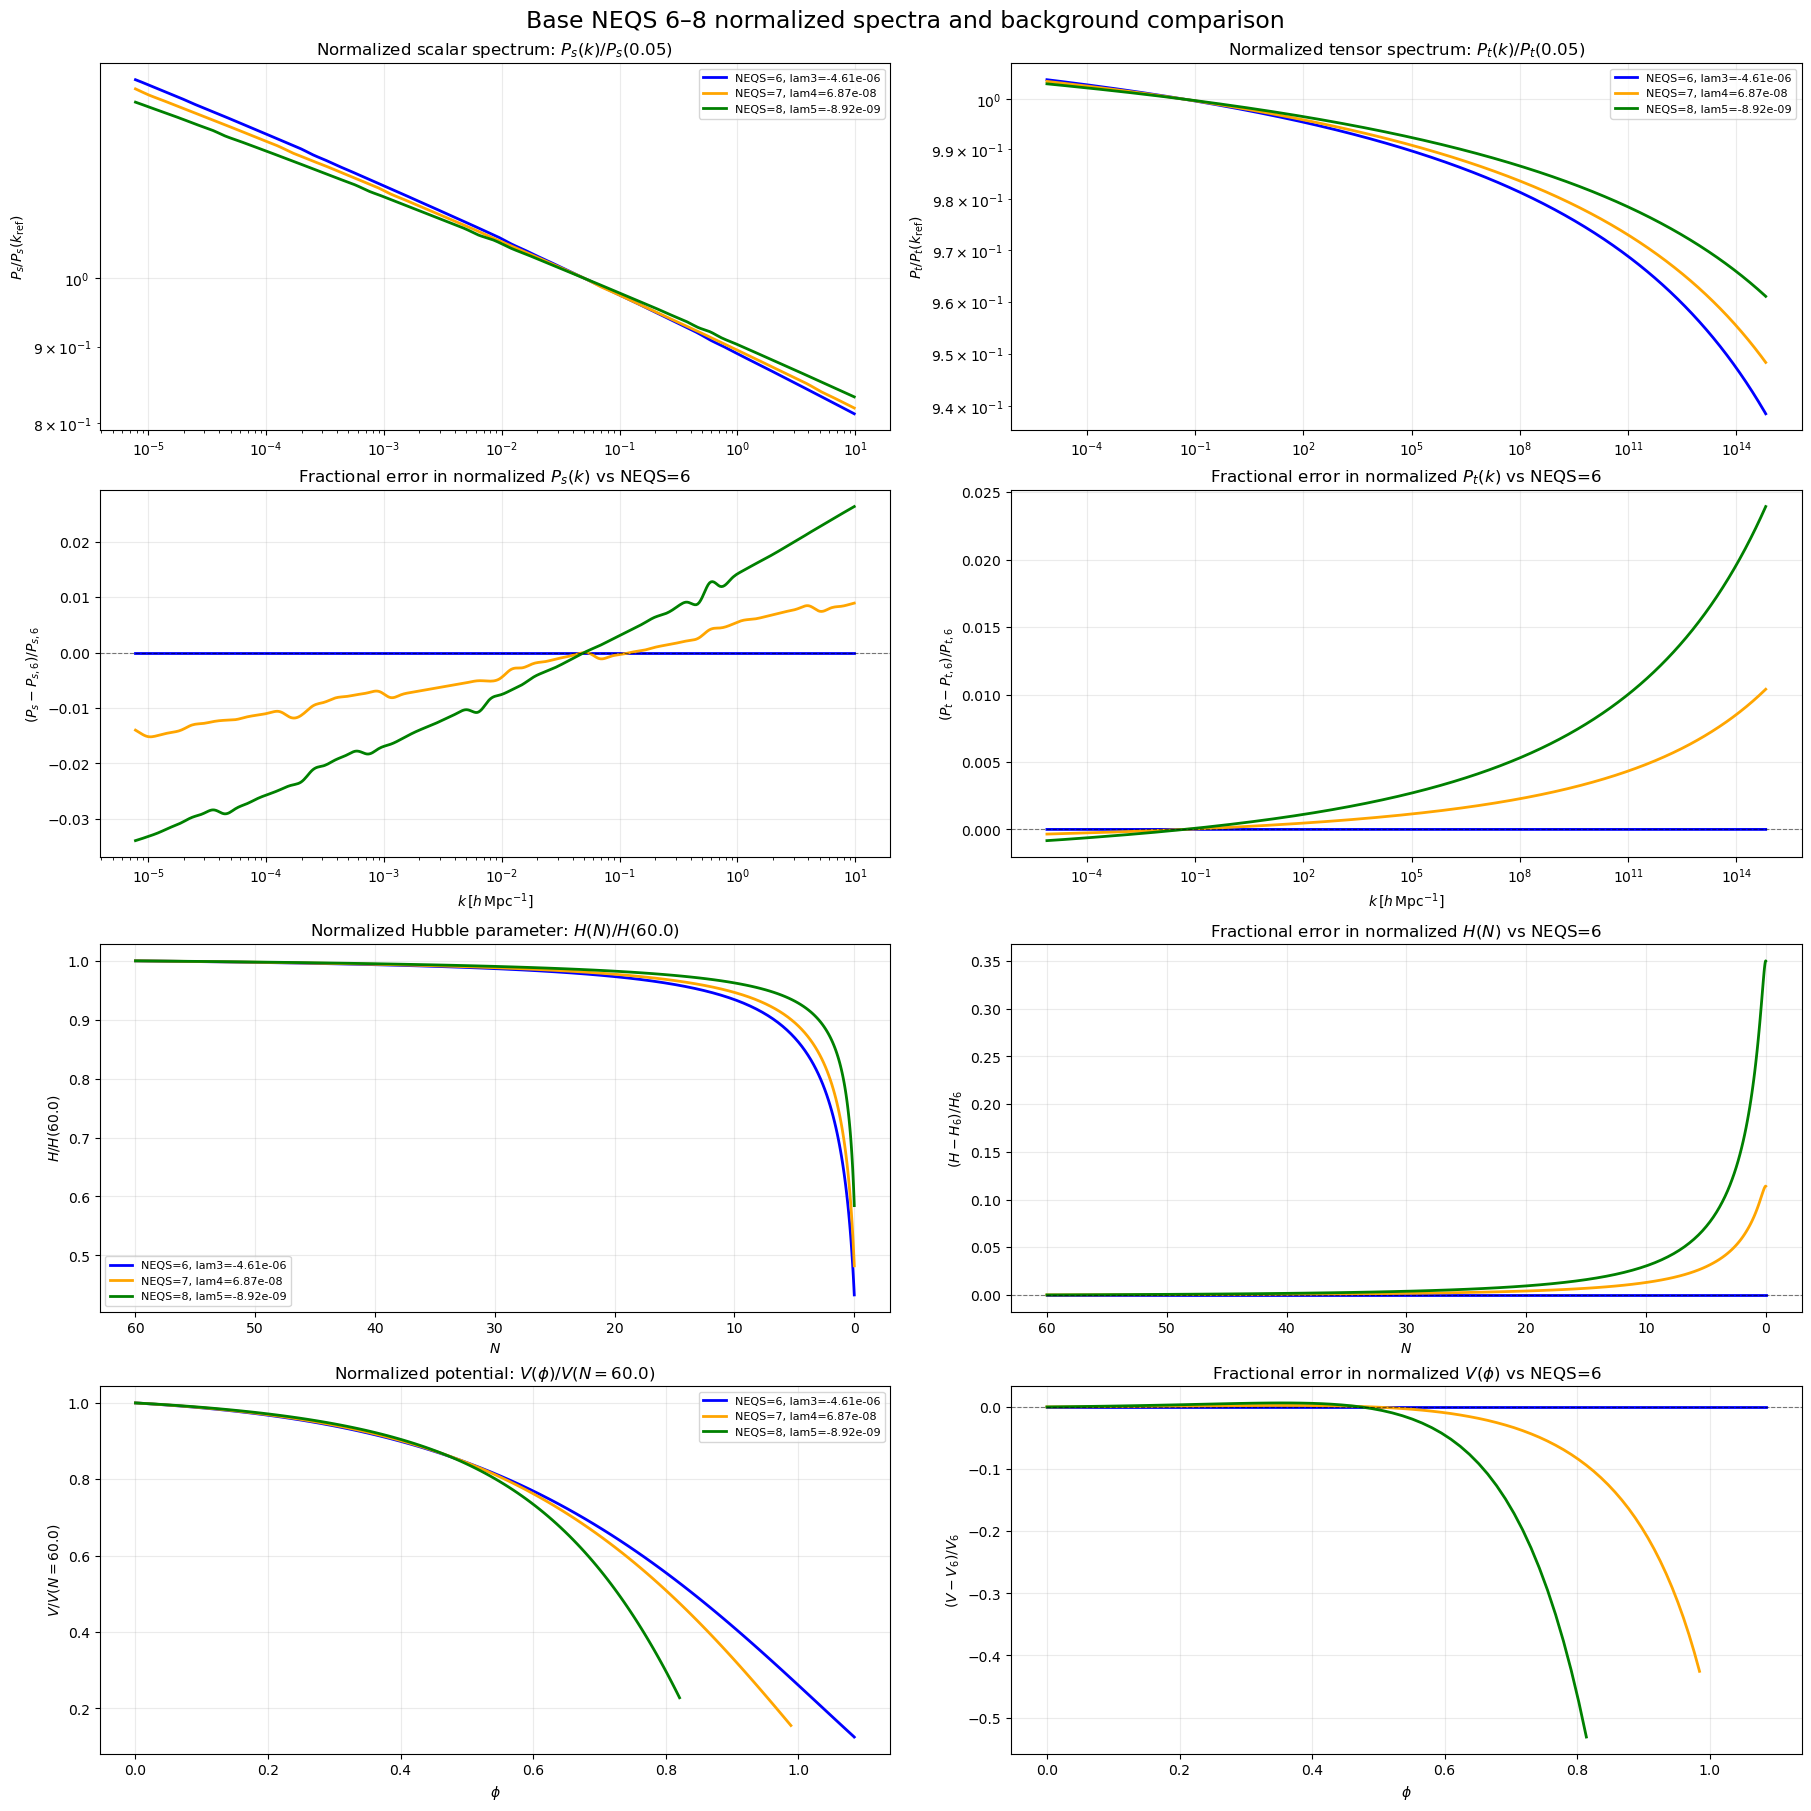


=== Summary Statistics (% difference from NEQS=6 base) ===

 NEQS param      value mean_dPs_pct max_dPs_pct mean_dPt_pct max_dPt_pct mean_dH_pct max_dH_pct mean_dV_pct max_dV_pct
    6  lam3 -4.610e-06       0.000%      0.000%       0.000%      0.000%      0.000%     0.000%      0.000%     0.000%
    7  lam4  6.871e-08      -0.360%      1.520%       0.216%      1.039%      4.847%    11.406%     -6.378%    42.549%
    8  lam5 -8.925e-09      -0.655%      3.392%       0.501%      2.394%     13.729%    35.026%     -6.660%    53.120%


In [31]:
base_stats_df = plot_big_base_curves_summary_neqs6_8(
    base_path_root=base_path_root,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1.0,
    V_scale=1.0,
    save_name="base_neqs6_8_big_normalized_summary.png",
    suptitle="Base NEQS 6–8 normalized spectra and background comparison",
)

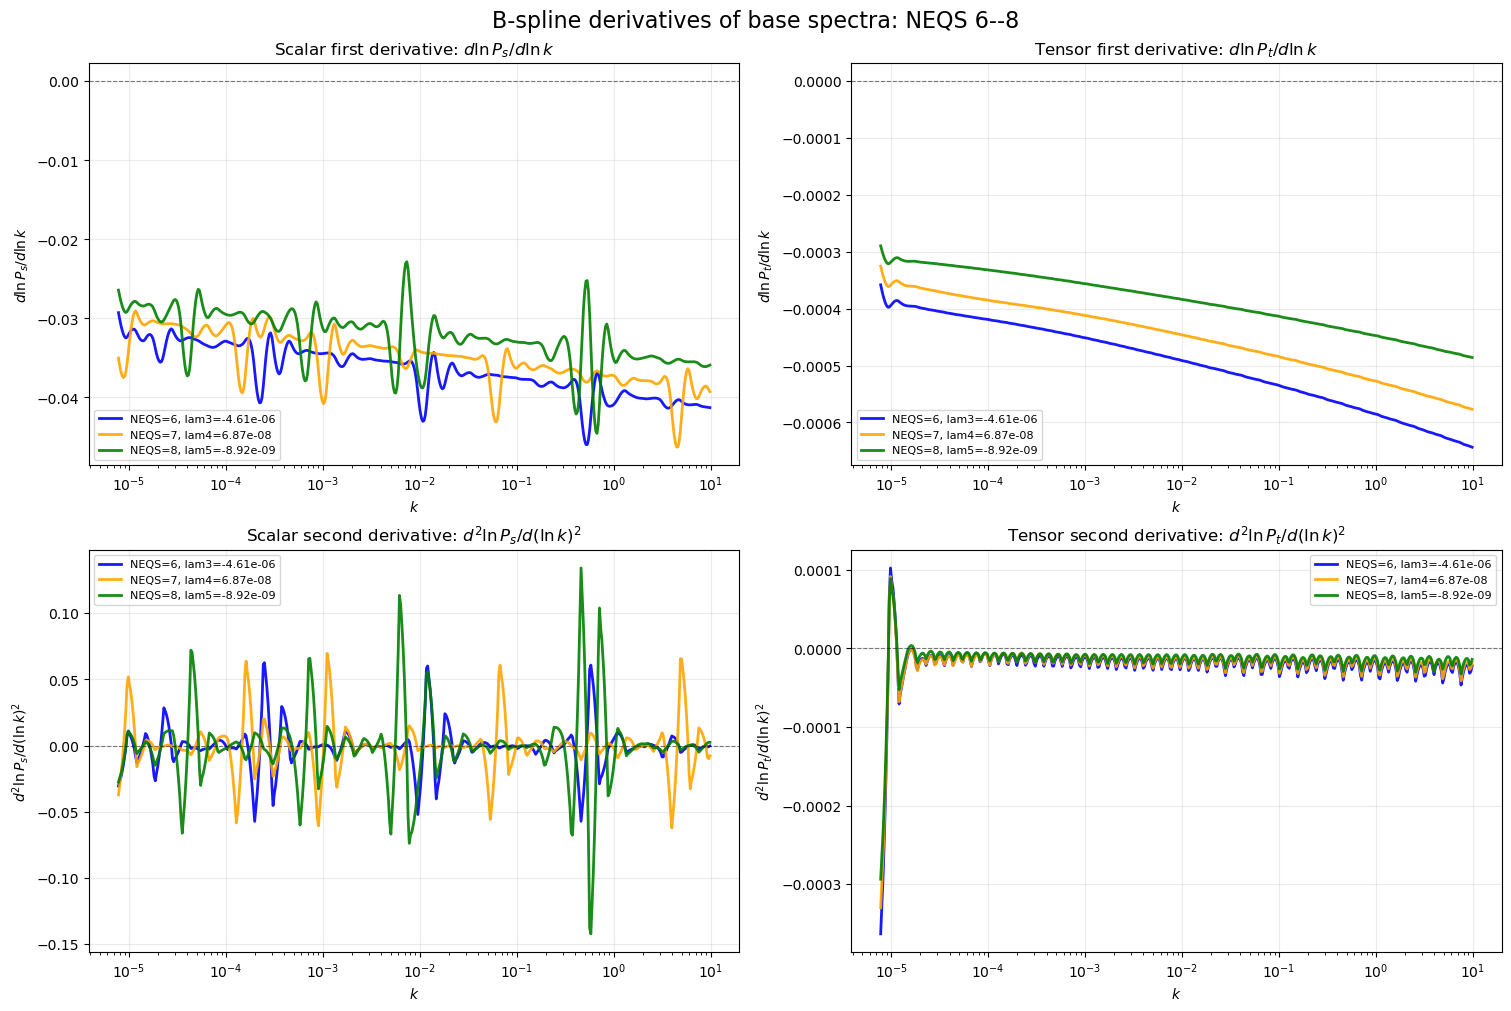

In [11]:
def plot_base_spectra_derivatives_bspline_2x2(
    base_path_root,
    base_params=None,
    k_min_plot=None,
    k_max_plot=None,
    smoothing=0.0,
    save_name=None,
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import UnivariateSpline

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    colors = {
        6: "blue",
        7: "orange",
        8: "green",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}"
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (k > 0) & (P > 0) & np.isfinite(k) & np.isfinite(P)
        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        x_unique, idx = np.unique(x, return_index=True)
        y_unique = y[idx]

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        d1 = spl.derivative(1)(x_unique)
        d2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), d1, d2

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    for NEQS, (param_name, value) in base_params.items():
        k_s, Ps, k_t, Pt = load_specs(NEQS, param_name, value)

        k_s_use, d1Ps, d2Ps = prepare_log_spline(k_s, Ps, smoothing=smoothing)
        k_t_use, d1Pt, d2Pt = prepare_log_spline(k_t, Pt, smoothing=smoothing)

        mask_s = np.ones_like(k_s_use, dtype=bool)
        mask_t = np.ones_like(k_t_use, dtype=bool)

        if k_min_plot is not None:
            mask_s &= k_s_use >= k_min_plot
            mask_t &= k_t_use >= k_min_plot

        if k_max_plot is not None:
            mask_s &= k_s_use <= k_max_plot
            mask_t &= k_t_use <= k_max_plot

        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"
        color = colors.get(NEQS, None)

        ax_d1Ps.semilogx(
            k_s_use[mask_s], d1Ps[mask_s],
            color=color, lw=2.0, alpha=0.9, label=label
        )

        ax_d1Pt.semilogx(
            k_t_use[mask_t], d1Pt[mask_t],
            color=color, lw=2.0, alpha=0.9, label=label
        )

        ax_d2Ps.semilogx(
            k_s_use[mask_s], d2Ps[mask_s],
            color=color, lw=2.0, alpha=0.9, label=label
        )

        ax_d2Pt.semilogx(
            k_t_use[mask_t], d2Pt[mask_t],
            color=color, lw=2.0, alpha=0.9, label=label
        )

    ax_d1Ps.set_title(r"Scalar first derivative: $d\ln P_s / d\ln k$")
    ax_d1Pt.set_title(r"Tensor first derivative: $d\ln P_t / d\ln k$")
    ax_d2Ps.set_title(r"Scalar second derivative: $d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_title(r"Tensor second derivative: $d^2\ln P_t / d(\ln k)^2$")

    for ax in axes.ravel():
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xlabel(r"$k$")
        ax.grid(True, alpha=0.25)
        ax.legend(fontsize=8)

    ax_d1Ps.set_ylabel(r"$d\ln P_s / d\ln k$")
    ax_d1Pt.set_ylabel(r"$d\ln P_t / d\ln k$")
    ax_d2Ps.set_ylabel(r"$d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_ylabel(r"$d^2\ln P_t / d(\ln k)^2$")

    fig.suptitle(
        rf"B-spline derivatives of base spectra: NEQS 6--8",
        fontsize=16,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    plt.show()
    
    
plot_base_spectra_derivatives_bspline_2x2(
    base_path_root=base_path_root,
    k_min_plot=None,
    k_max_plot=10.0,
    smoothing=0.0,
    save_name="base_spectra_derivatives_neqs6_8.png",
)

In [32]:
def plot_restored_original_trajectories_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    colors = {
        6: "blue",
        7: "orange",
        8: "green",
    }

    def load_path(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )
        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
        )

        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]
        H = data[:, 1]

        order = np.argsort(N)
        return N[order], eps[order], sigma[order], lam2[order], H[order]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    ax_eps, ax_sig = axes[0]
    ax_lam2, ax_H = axes[1]

    for NEQS, (param_name, value) in base_params.items():
        row = base_summary_df.loc[base_summary_df["NEQS"] == NEQS].iloc[0]
        original_N_end = row["original_N_end"]

        N_recon, eps, sigma, lam2, H = load_path(NEQS, param_name, value)

        N_restored = original_N_end + N_recon
        H_norm = H / np.interp(60.0, N_recon, H)

        label = rf"NEQS={NEQS}, {param_name}={value:.2e}"

        ax_eps.plot(
            N_restored, eps,
            color=colors.get(NEQS), lw=2.2, alpha=0.9, label=label
        )
        ax_sig.plot(
            N_restored, sigma,
            color=colors.get(NEQS), lw=2.2, alpha=0.9, label=label
        )
        ax_lam2.plot(
            N_restored, lam2,
            color=colors.get(NEQS), lw=2.2, alpha=0.9, label=label
        )
        ax_H.plot(
            N_restored, H_norm,
            color=colors.get(NEQS), lw=2.2, alpha=0.9, label=label
        )

    ax_eps.set_title(r"Restored original-coordinate $\epsilon$")
    ax_sig.set_title(r"Restored original-coordinate $\sigma$")
    ax_lam2.set_title(r"Restored original-coordinate $\lambda_2$")
    ax_H.set_title(r"Restored original-coordinate $H/H(N_{\rm recon}=60)$")

    ax_eps.set_yscale("log")

    for ax in axes.ravel():
        ax.set_xlabel(
            r"Approximate original e-fold coordinate "
            r"$N_{\epsilon=1}^{\rm orig}+N_{\rm recon}$"
        )
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    ax_eps.set_ylabel(r"$\epsilon$")
    ax_sig.set_ylabel(r"$\sigma$")
    ax_lam2.set_ylabel(r"$\lambda_2$")
    ax_H.set_ylabel(r"$H/H(60)$")

    fig.suptitle(
        r"Restored original-coordinate base trajectories: NEQS 6--8",
        fontsize=15,
    )

    plt.show()

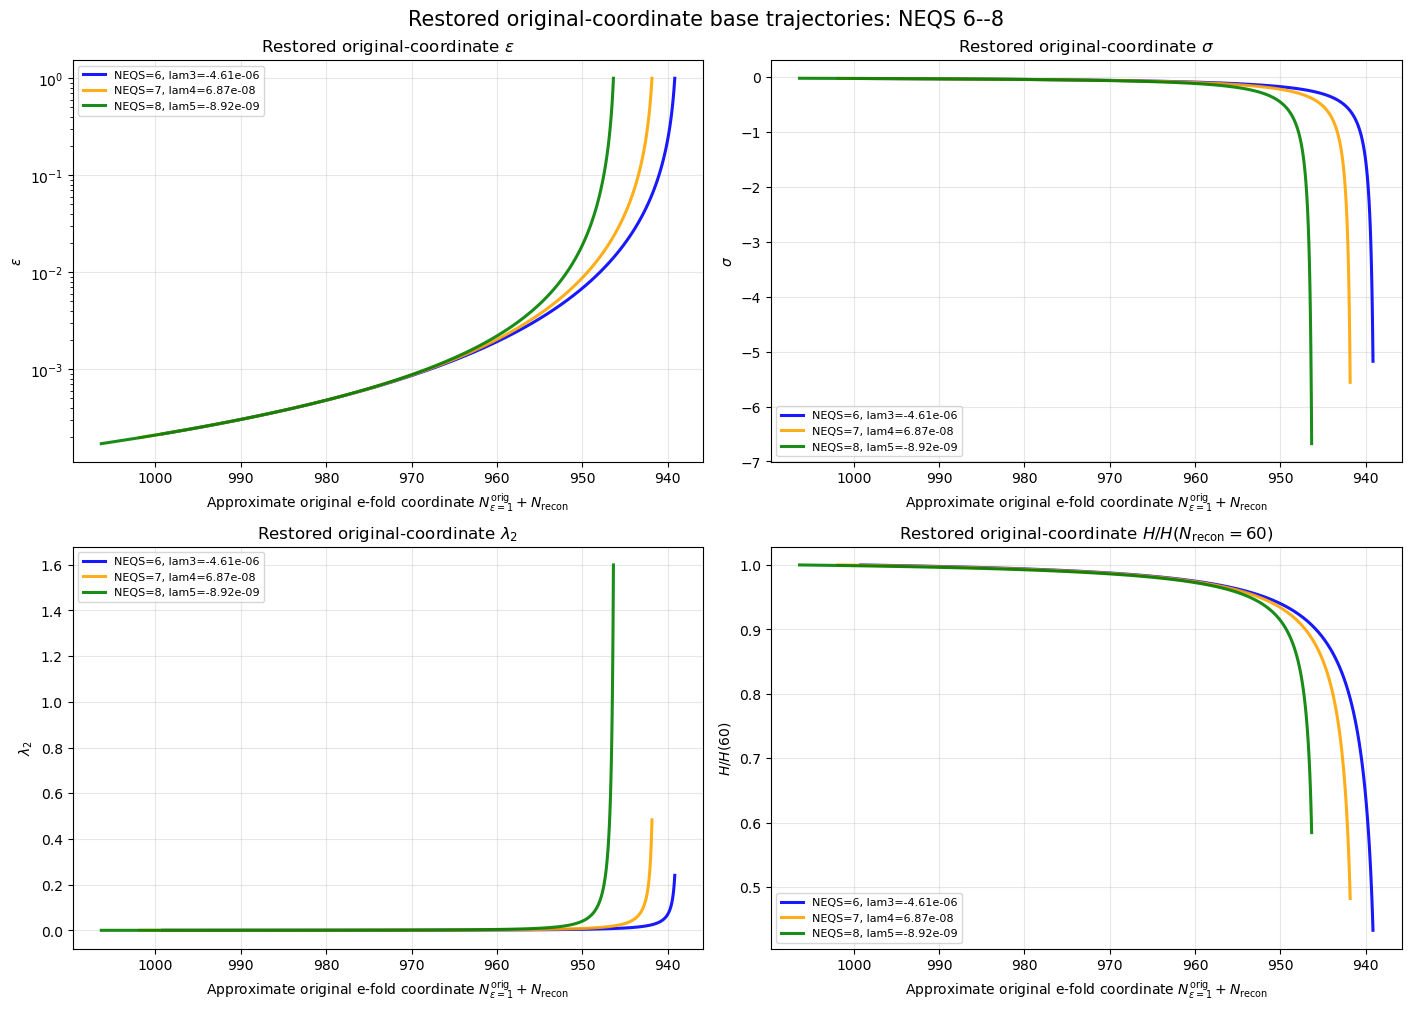

In [33]:
plot_restored_original_trajectories_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
)

In [34]:
def plot_unshifted_vs_shifted_eps_H_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    colors = {
        6: "blue",
        7: "orange",
        8: "green",
    }

    def load_path(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )
        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
        )

        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        H = data[:, 1]

        order = np.argsort(N)
        return N[order], eps[order], H[order]

    ref_row = base_summary_df.loc[base_summary_df["NEQS"] == ref_NEQS].iloc[0]
    ref_N_end = ref_row["original_N_end"]

    ref_param, ref_value = base_params[ref_NEQS]
    N_ref_curve, eps_ref, H_ref = load_path(ref_NEQS, ref_param, ref_value)
    H_ref_norm = H_ref / np.interp(60.0, N_ref_curve, H_ref)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    ax_eps_un, ax_eps_sh = axes[0]
    ax_H_un, ax_H_sh = axes[1]

    # Reference/base curves
    ax_eps_un.plot(N_ref_curve, eps_ref, color="black", lw=3, ls="--", label=f"NEQS={ref_NEQS} ref")
    ax_eps_sh.plot(N_ref_curve, eps_ref, color="black", lw=3, ls="--", label=f"NEQS={ref_NEQS} ref")

    ax_H_un.plot(N_ref_curve, H_ref_norm, color="black", lw=3, ls="--", label=f"NEQS={ref_NEQS} ref")
    ax_H_sh.plot(N_ref_curve, H_ref_norm, color="black", lw=3, ls="--", label=f"NEQS={ref_NEQS} ref")

    for NEQS, (param_name, value) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        row = base_summary_df.loc[base_summary_df["NEQS"] == NEQS].iloc[0]
        deltaN = row["original_N_end"] - ref_N_end

        N, eps, H = load_path(NEQS, param_name, value)
        H_norm = H / np.interp(60.0, N, H)

        label = rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"

        # unshifted reconstructed coordinate
        ax_eps_un.plot(N, eps, color=colors.get(NEQS), lw=2, alpha=0.85, label=label)
        ax_H_un.plot(N, H_norm, color=colors.get(NEQS), lw=2, alpha=0.85, label=label)

        # shifted by original end offset
        ax_eps_sh.plot(N + deltaN, eps, color=colors.get(NEQS), lw=2, alpha=0.85, label=label)
        ax_H_sh.plot(N + deltaN, H_norm, color=colors.get(NEQS), lw=2, alpha=0.85, label=label)

    ax_eps_un.set_title(r"Unshifted $\epsilon(N_{\rm recon})$")
    ax_eps_sh.set_title(r"Shifted $\epsilon(N_{\rm recon}+\Delta N_{\rm end})$")

    ax_H_un.set_title(r"Unshifted $H(N_{\rm recon})/H(60)$")
    ax_H_sh.set_title(r"Shifted $H(N_{\rm recon}+\Delta N_{\rm end})/H(60)$")

    for ax in [ax_eps_un, ax_eps_sh]:
        ax.set_yscale("log")
        ax.set_ylabel(r"$\epsilon$")

    for ax in [ax_H_un, ax_H_sh]:
        ax.set_ylabel(r"$H/H(60)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()
        ax.legend(fontsize=8)

    fig.suptitle("Base NEQS 6–8: unshifted vs original-end shifted comparison", fontsize=15)
    plt.show()

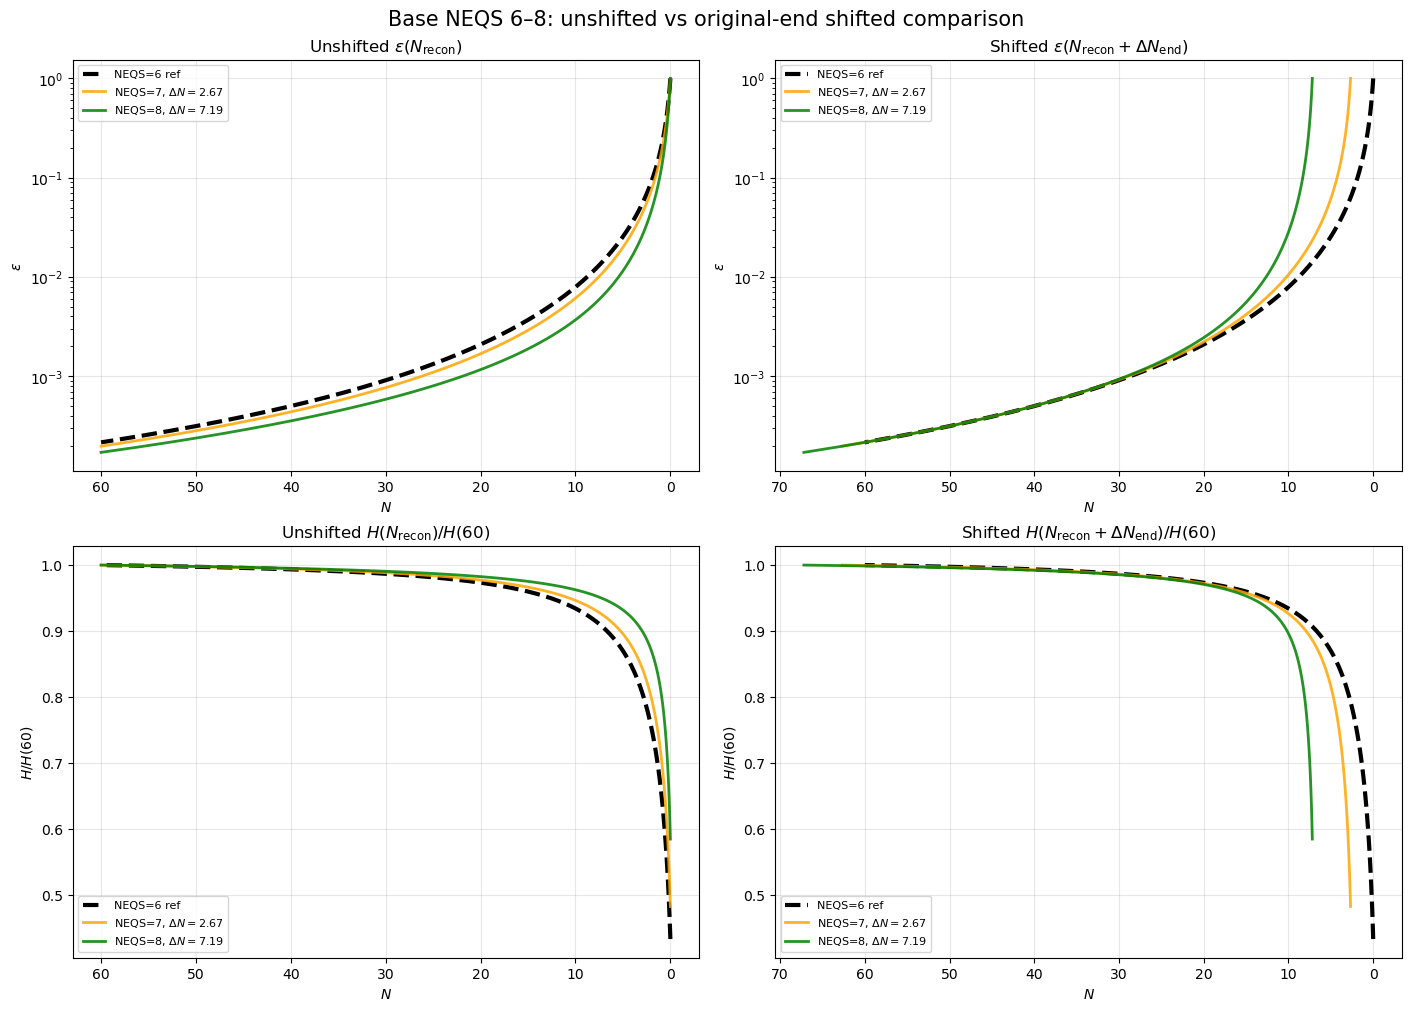

In [35]:
plot_unshifted_vs_shifted_eps_H_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
)

In [72]:
def find_shift_breakdown_base_neqs6_8(
    base_path_root,
    base_summary_df,
    base_params=None,
    ref_NEQS=6,
    eps_tol=0.05,   # 5% tolerance
    H_tol=0.005,    # 0.5% tolerance
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    if base_params is None:
        base_params = {
            6: ("lam3", -4.60971e-6),
            7: ("lam4",  6.87065e-8),
            8: ("lam5", -8.92461e-9),
        }

    colors = {6: "blue", 7: "orange", 8: "green"}

    def load_path(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{param_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{param_name}_{val_str}.dat")

        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        H = data[:, 1]

        order = np.argsort(N)
        return N[order], eps[order], H[order]

    ref_row = base_summary_df.loc[base_summary_df["NEQS"] == ref_NEQS].iloc[0]
    ref_N_end = ref_row["original_N_end"]

    ref_param, ref_value = base_params[ref_NEQS]
    N_ref, eps_ref, H_ref = load_path(ref_NEQS, ref_param, ref_value)
    H_ref_norm = H_ref / np.interp(60.0, N_ref, H_ref)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    ax_eps, ax_H = axes

    rows = []

    for NEQS, (param_name, value) in base_params.items():
        if NEQS == ref_NEQS:
            continue

        row = base_summary_df.loc[base_summary_df["NEQS"] == NEQS].iloc[0]
        deltaN = row["original_N_end"] - ref_N_end

        N, eps, H = load_path(NEQS, param_name, value)
        H_norm = H / np.interp(60.0, N, H)

        # Match your shifted plot convention
        N_shift = N + deltaN

        # Compare only where shifted curve overlaps the reference curve
        xmin = max(N_ref.min(), N_shift.min())
        xmax = min(N_ref.max(), N_shift.max())

        mask_ref = (N_ref >= xmin) & (N_ref <= xmax)
        N_common = N_ref[mask_ref]

        eps_shift_interp = np.interp(N_common, N_shift, eps)
        H_shift_interp = np.interp(N_common, N_shift, H_norm)

        eps_ref_common = eps_ref[mask_ref]
        H_ref_common = H_ref_norm[mask_ref]

        frac_eps = (eps_shift_interp - eps_ref_common) / eps_ref_common
        frac_H = (H_shift_interp - H_ref_common) / H_ref_common

        ax_eps.plot(
            N_common, frac_eps,
            color=colors.get(NEQS), lw=2,
            label=rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"
        )

        ax_H.plot(
            N_common, frac_H,
            color=colors.get(NEQS), lw=2,
            label=rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$"
        )

        # Since axes are inverted, "moving toward end" means N decreases.
        # Find where error first exceeds tolerance as we go from high N to low N.
        order_desc = np.argsort(N_common)[::-1]
        N_desc = N_common[order_desc]
        eps_err_desc = np.abs(frac_eps[order_desc])
        H_err_desc = np.abs(frac_H[order_desc])

        eps_bad = np.where(eps_err_desc > eps_tol)[0]
        H_bad = np.where(H_err_desc > H_tol)[0]

        eps_break_N = N_desc[eps_bad[0]] if len(eps_bad) else np.nan
        H_break_N = N_desc[H_bad[0]] if len(H_bad) else np.nan

        rows.append({
            "NEQS": NEQS,
            "deltaN": deltaN,
            "N_overlap_min": xmin,
            "N_overlap_max": xmax,
            f"N_break_eps_{100*eps_tol:.1f}pct": eps_break_N,
            f"N_break_H_{100*H_tol:.2f}pct": H_break_N,
            "max_abs_frac_eps_pct": 100*np.nanmax(np.abs(frac_eps)),
            "max_abs_frac_H_pct": 100*np.nanmax(np.abs(frac_H)),
        })

    ax_eps.axhline(0, color="black", ls="--", alpha=0.5)
    ax_eps.axhline(eps_tol, color="black", ls=":", alpha=0.5)
    ax_eps.axhline(-eps_tol, color="black", ls=":", alpha=0.5)

    ax_H.axhline(0, color="black", ls="--", alpha=0.5)
    ax_H.axhline(H_tol, color="black", ls=":", alpha=0.5)
    ax_H.axhline(-H_tol, color="black", ls=":", alpha=0.5)

    ax_eps.set_title(r"Shifted $\epsilon$ fractional error vs NEQS=6")
    ax_H.set_title(r"Shifted $H/H(60)$ fractional error vs NEQS=6")

    ax_eps.set_ylabel(r"$(\epsilon_{\rm shifted}-\epsilon_6)/\epsilon_6$")
    ax_H.set_ylabel(r"$(H_{\rm shifted}-H_6)/H_6$")

    for ax in axes:
        ax.set_xlabel(r"$N$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        
    plt.figure()
    plt.plot(N_ref, np.zeros_like(N_ref), label="base grid")
    plt.scatter(N_common, np.zeros_like(N_common), s=5, label="common grid")
    plt.legend()
    plt.show()

    plt.show()

    return pd.DataFrame(rows)

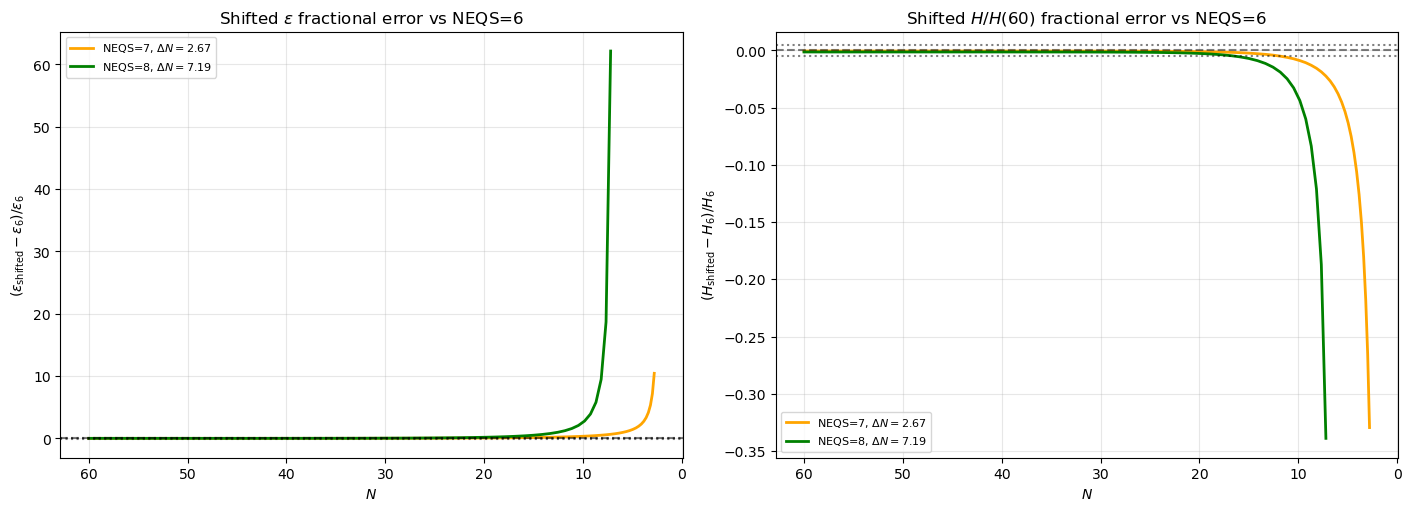

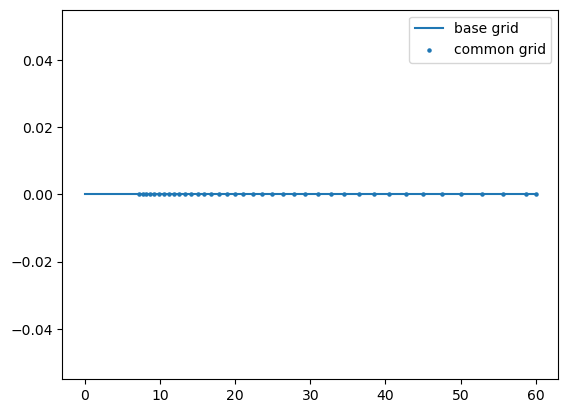

 NEQS   deltaN  N_overlap_min  N_overlap_max  N_break_eps_5.0pct  N_break_H_0.50pct  max_abs_frac_eps_pct  max_abs_frac_H_pct
    7 2.673499       2.673500           60.0           21.099511          11.828765           1043.434669           32.955647
    8 7.186161       7.186162           60.0           26.320711          15.884139           6214.535313           33.898062


In [73]:
breakdown_df = find_shift_breakdown_base_neqs6_8(
    base_path_root=base_path_root,
    base_summary_df=base_summary_df,
    eps_tol=0.05,   # 5%
    H_tol=0.005,    # 0.5%
)

print(breakdown_df.to_string(index=False))

In [36]:
def print_base_model_comparison_table(base_summary_df):
    import numpy as np
    import pandas as pd

    # sort by NEQS just to be safe
    df = base_summary_df.sort_values("NEQS").copy()

    # reference (NEQS=6)
    ref = df[df["NEQS"] == 6].iloc[0]

    # compute differences relative to NEQS=6
    df["delta_N"] = df["original_N_end"] - ref["original_N_end"]
    df["delta_ns"] = df["n_s"] - ref["n_s"]
    df["delta_r"] = df["r"] - ref["r"]

    # percent changes
    df["pct_delta_ns"] = 100 * df["delta_ns"] / ref["n_s"]
    df["pct_delta_r"] = 100 * df["delta_r"] / ref["r"]

    # nice formatting
    display_df = df[[
        "NEQS",
        "param",
        "value",
        "original_N_end",
        "delta_N",
        "n_s",
        "delta_ns",
        "pct_delta_ns",
        "r",
        "delta_r",
        "pct_delta_r",
    ]].copy()

    display_df["value"] = display_df["value"].map(lambda x: f"{x:.3e}")
    display_df["original_N_end"] = display_df["original_N_end"].map(lambda x: f"{x:.3f}")
    display_df["delta_N"] = display_df["delta_N"].map(lambda x: f"{x:+.3f}")

    display_df["n_s"] = display_df["n_s"].map(lambda x: f"{x:.6f}")
    display_df["delta_ns"] = display_df["delta_ns"].map(lambda x: f"{x:+.6f}")
    display_df["pct_delta_ns"] = display_df["pct_delta_ns"].map(lambda x: f"{x:+.3f}%")

    display_df["r"] = display_df["r"].map(lambda x: f"{x:.6f}")
    display_df["delta_r"] = display_df["delta_r"].map(lambda x: f"{x:+.6f}")
    display_df["pct_delta_r"] = display_df["pct_delta_r"].map(lambda x: f"{x:+.3f}%")

    print("\n=== Base Model Comparison (relative to NEQS=6) ===\n")
    print(display_df.to_string(index=False))

    return df

In [37]:
comparison_df = print_base_model_comparison_table(base_summary_df)


=== Base Model Comparison (relative to NEQS=6) ===

 NEQS param      value original_N_end delta_N      n_s  delta_ns pct_delta_ns        r   delta_r pct_delta_r
    6  lam3 -4.610e-06        939.164  +0.000 0.965678 +0.000000      +0.000% 0.003454 +0.000000     +0.000%
    7  lam4  6.871e-08        941.837  +2.673 0.967201 +0.001523      +0.158% 0.003158 -0.000297     -8.588%
    8  lam5 -8.925e-09        946.350  +7.186 0.969485 +0.003807      +0.394% 0.002737 -0.000717    -20.760%


Increasing the truncation order does not simply reproduce the identical model at the same e-fold location. Instead, it shifts the effective location of the trajectory in N, and that shift propagates into the observables, producing a higher ns, lower r, and measurable differences in the spectra!!! More professionally, higher-order slow-roll terms act primarily like an N-shift along a similar inflationary trajectory, with small residual changes to the dynamics. Bruh how do we quantify how much it moves? Like why that much?

Relative to NEQS=6, NEQS=7 is shifted by +2.67 e-folds and NEQS=8 by +7.19 e-folds in the original end-of-inflation coordinate

In [65]:
def test_k_shift_equivalence(
    base_path_root,
    base_params,
    base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    def load_specs(NEQS, param, val):
        val_str = f"{val:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{param}_{val_str}")
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        k = s[:, 0]
        Ps = np.abs(s[:, 1])
        order = np.argsort(k)
        return k[order], Ps[order]
    
#load reference spectrum
    ref_param, ref_val = base_params[ref_NEQS]
    k_ref, Ps_ref = load_specs(ref_NEQS, ref_param, ref_val)
    Ps_ref = Ps_ref / np.interp(k_norm, k_ref, Ps_ref) #normalize her

    plt.figure(figsize=(7, 5))
    k_max_plot=10.0
    mask_ref = k_ref <= k_max_plot

    plt.loglog(k_ref[mask_ref], Ps_ref[mask_ref], lw=3, color="black", label=f"NEQS={ref_NEQS} reference",linestyle="--")

    ref_N_end = base_summary_df.loc[
        base_summary_df["NEQS"] == ref_NEQS, "original_N_end"
    ].iloc[0]

    for NEQS, (param, val) in base_params.items():
        if NEQS == ref_NEQS:
            continue
            
        N_end = base_summary_df.loc[
            base_summary_df["NEQS"] == NEQS, "original_N_end"
        ].iloc[0]

        deltaN = N_end - ref_N_end #this is physical difference in inflation duration

        k, Ps = load_specs(NEQS, param, val)
        k_shifted = k * np.exp(-deltaN) #this is Ps = Ps * ke^-deltaN
        #should tell us where the mode would have exited in the reference timeline
        Ps = Ps / np.interp(k_norm, k_shifted, Ps) #normalize 
#so we compare all models at same physical scale after correcting for timing differences
       

        # For an N-shift, compare P_model(k * exp(-deltaN)) against reference.
        mask = k_shifted <= k_max_plot

        plt.loglog(
            k_shifted[mask],
            Ps[mask],
            lw=2,
            label=rf"NEQS={NEQS}, $\Delta N={deltaN:.2f}$",linestyle="--"
        )

    plt.axvline(k_norm, color="black", ls=":", alpha=0.6)
    plt.xlabel(r"shifted $k$")
    plt.ylabel(rf"$P_s/P_s(k={k_norm})$")
    plt.title(r"Testing whether base spectra differ by a $k$-shift")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

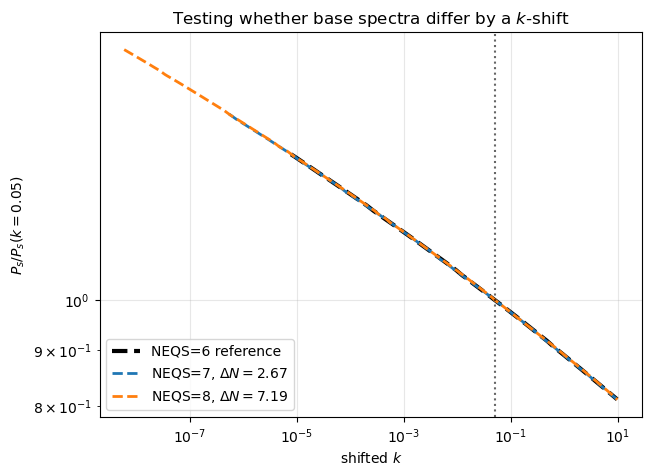

In [66]:
BASE_PARAMS = {
    6: ("lam3", -4.60971e-6),
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
}

test_k_shift_equivalence(
    base_path_root=base_path_root,
    base_params=BASE_PARAMS,
    base_summary_df=base_summary_df,
    ref_NEQS=6,
    k_norm=0.05,
)

Increasing the slow-roll hierarchy order primarily shifts the inflationary trajectory in e-fold time. This shift translates into a rescaling of the horizon-crossing condition k∼e
N
H, which manifests as a horizontal shift in the power spectrum. After accounting for this shift, the scalar spectra collapse onto a single curve, indicating that the underlying inflationary dynamics are nearly identical.